In [1]:
import pandas as pd
import seaborn as sns

In [2]:
data = pd.read_csv("HousePricePrediction.csv")

In [3]:
data.sample(410)

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
2089,2089,75,RM,6000,Inside,1Fam,7,1915,2005,Wd Sdng,0.0,728.0,NaN
288,288,20,RL,9819,Inside,1Fam,5,1967,1967,MetalSd,0.0,882.0,122000.0
1332,1332,20,RL,8877,Inside,1Fam,6,1938,1958,MetalSd,0.0,816.0,100000.0
2763,2763,20,RL,11650,Corner,1Fam,5,1959,1959,Plywood,0.0,0.0,NaN
2421,2421,20,RL,15783,Inside,1Fam,5,1952,1952,Wd Sdng,0.0,924.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1719,1719,20,RL,10141,Inside,1Fam,5,2004,2004,VinylSd,774.0,1512.0,NaN
2373,2373,60,FV,8413,Inside,1Fam,5,1998,1998,VinylSd,0.0,1220.0,NaN
253,253,80,RL,9350,Inside,1Fam,7,1964,1991,HdBoard,580.0,1302.0,158000.0
1776,1776,30,RL,8480,Corner,1Fam,6,1945,1950,MetalSd,0.0,793.0,NaN


In [4]:
data.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


<Axes: xlabel='LotArea', ylabel='SalePrice'>

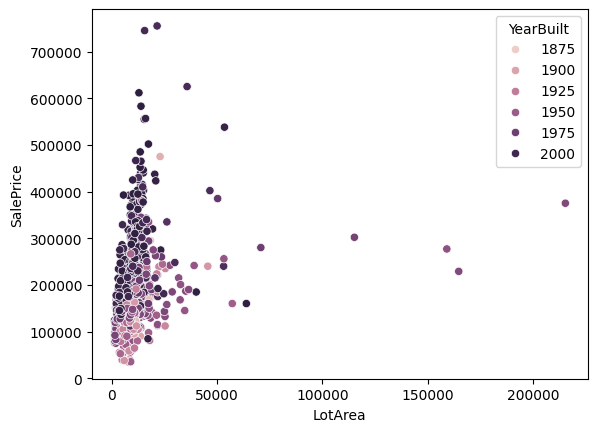

In [6]:
sns.scatterplot(x=data["LotArea"],y=data["SalePrice"],hue=data["YearBuilt"])

In [7]:
# These are the outliers :
data[data["LotArea"]>100000]

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
249,249,50,RL,159000,CulDSac,1Fam,7,1958,2006,Wd Sdng,0.0,1444.0,277000.0
313,313,20,RL,215245,Inside,1Fam,5,1965,1965,BrkFace,820.0,2136.0,375000.0
335,335,190,RL,164660,Corner,2fmCon,6,1965,1965,Plywood,147.0,1499.0,228950.0
706,706,20,RL,115149,CulDSac,1Fam,5,1971,2002,Plywood,0.0,1643.0,302000.0


In [8]:
# Remove the outliers :
data.drop(data[data["LotArea"]>100000].index,inplace=True)

<Axes: xlabel='LotArea', ylabel='SalePrice'>

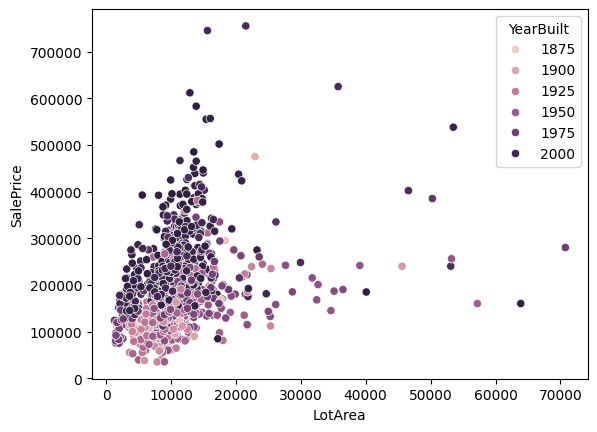

In [9]:
# Revisualize :

sns.scatterplot(x=data["LotArea"],y=data["SalePrice"],hue=data["YearBuilt"])

In [10]:
# Remove the outliers :
data.drop(data[data["LotArea"]>38000].index,inplace=True)
data.drop(data[data["SalePrice"]>650000].index,inplace=True)

<Axes: xlabel='LotArea', ylabel='SalePrice'>

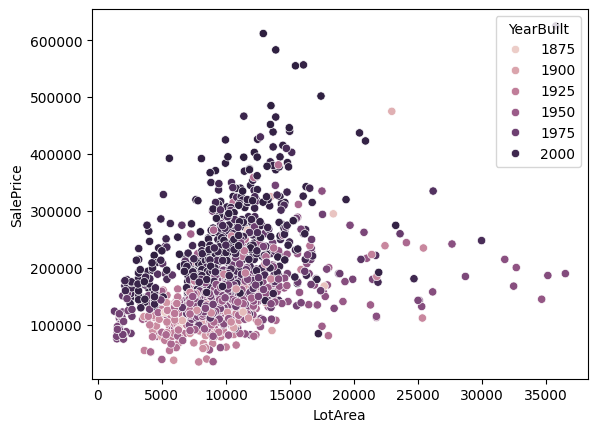

In [11]:
# Revisualize :

sns.scatterplot(x=data["LotArea"],y=data["SalePrice"],hue=data["YearBuilt"])

In [12]:
# As 50% House Prices are missing so it's better to remove them rather than impute!

data.dropna(inplace=True)
data

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1455,60,RL,7917,Inside,1Fam,5,1999,2000,VinylSd,0.0,953.0,175000.0
1456,1456,20,RL,13175,Inside,1Fam,6,1978,1988,Plywood,163.0,1542.0,210000.0
1457,1457,70,RL,9042,Inside,1Fam,9,1941,2006,CemntBd,0.0,1152.0,266500.0
1458,1458,20,RL,9717,Inside,1Fam,6,1950,1996,MetalSd,1029.0,1078.0,142125.0


In [13]:
# Remove the index column :

data.drop("Id",axis=1,inplace=True)
data

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,7917,Inside,1Fam,5,1999,2000,VinylSd,0.0,953.0,175000.0
1456,20,RL,13175,Inside,1Fam,6,1978,1988,Plywood,163.0,1542.0,210000.0
1457,70,RL,9042,Inside,1Fam,9,1941,2006,CemntBd,0.0,1152.0,266500.0
1458,20,RL,9717,Inside,1Fam,6,1950,1996,MetalSd,1029.0,1078.0,142125.0


In [14]:
# Overview of the data for the encoding:

print(data["MSZoning"].value_counts())
print(data["LotConfig"].value_counts())
print(data["Exterior1st"].value_counts())
print(data["BldgType"].value_counts())

MSZoning
RL         1134
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64
LotConfig
Inside     1046
Corner      258
CulDSac      88
FR2          47
FR3           4
Name: count, dtype: int64
Exterior1st
VinylSd    514
MetalSd    220
HdBoard    220
Wd Sdng    202
Plywood    103
CemntBd     59
BrkFace     49
WdShing     25
Stucco      24
AsbShng     20
BrkComm      2
Stone        2
AsphShn      1
ImStucc      1
CBlock       1
Name: count, dtype: int64
BldgType
1Fam      1204
TwnhsE     114
Duplex      52
Twnhs       43
2fmCon      30
Name: count, dtype: int64


In [15]:
data["MSZoning"]=data["MSZoning"].map({"RL":0,"RM":1,"FV":2,"RH":3,"C (all)":4})
data["LotConfig"]=data["LotConfig"].map({"Inside":0,"Corner":1,"CulDSac":2,"FR2":3,"FR3":4})
data["Exterior1st"]=data["Exterior1st"].map({"VinylSd":0,"MetalSd":1,"HdBoard":2,"Wd Sdng":3,"Plywood":4,
"CemntBd":5,"BrkFace":6,"WdShing":7,"Stucco":8,"AsbShng":9,"BrkComm":10,"Stone":11,"AsphShn":12,"ImStucc":13,"CBlock":14})
data["BldgType"]=data["BldgType"].map({"1Fam":0,"TwnhsE":1,"FV":2,"Duplex":3,"Twnhs":4,"2fmCon":5})

In [17]:
X = data.drop("SalePrice",axis=1)
Y = data["SalePrice"]

In [18]:
# Train - Test - Split : 

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [19]:
# First Model of my life :

# Model Training Phase :

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[ 517.18,1664.07, 4.54,...,1809.75, -31.36, 87.33]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['MSSubClass','MSZoning','LotArea',...,'Exterior1st','BsmtFinSF2', 'TotalBsmtSF']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.876e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,11


In [20]:
# Making the value prediction :

y_pred = model.predict(X_test)

In [21]:
# Pair for the comparisons :

pair = [(int(x),y) for x,y in zip(y_pred,Y_test)]
print(pair)

[(145962, 142000.0), (267781, 342643.0), (134743, 115000.0), (296926, 180000.0), (118811, 97000.0), (98527, 103600.0), (212891, 211000.0), (77309, 100000.0), (158124, 97500.0), (75859, 94500.0), (257036, 274900.0), (197623, 250000.0), (98169, 112000.0), (218240, 230000.0), (118013, 118000.0), (168050, 135000.0), (274943, 245500.0), (326676, 415298.0), (152806, 171000.0), (208225, 194500.0), (249826, 262500.0), (122441, 110500.0), (268463, 275000.0), (223024, 177000.0), (41302, 82000.0), (233466, 270000.0), (92541, 151000.0), (170555, 207000.0), (101356, 114500.0), (193533, 141000.0), (200600, 179000.0), (262611, 228000.0), (253644, 241500.0), (146117, 110000.0), (130185, 119000.0), (155028, 225000.0), (139156, 127000.0), (197793, 212000.0), (209488, 195000.0), (57498, 68500.0), (165000, 130000.0), (210105, 184900.0), (118323, 136000.0), (100691, 124000.0), (182919, 173000.0), (214266, 179000.0), (79138, 80000.0), (180342, 256000.0), (189695, 188000.0), (325973, 385000.0), (115533, 1370

In [22]:
# Evaluation Metrics :

In [23]:
# 1] R Squared :

from sklearn.metrics import r2_score
r_square = r2_score(Y_test, y_pred)
print(f"R square value : {r_square} ")

R square value : 0.6410613820960356 


In [24]:
# 2 Adjusted R Squared :

# No. of rows :
n = X_test.shape[0]
print(X_test.shape[0])

# No. of cols :
p = X_test.shape[1]
print(X_test.shape[1])


r_adjusted = 1-(((1-r_square)*(n-1))/(n-p-1))

print(f"Adjusted R Square Value :{r_adjusted}")

289
11
Adjusted R Square Value :0.6268075019626651
